# RPG Graph Story

Concise notebook for the graph-analysis story. The goal is not to show every diagnostic, but only the figures/tables that are useful for the main text.

**Graph question.** Does RPG's graph-decoding saturation come from a poor graph, limited reachability, or the scorer/ranker after candidates are reached?

In [12]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'rpg-matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'RPG' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

GRAPH_ROOT = REPO_ROOT / 'artifacts' / 'rpg' / 'graph_analysis'
DATASETS = [
    {'dataset': 'Sports', 'slug': 'sports', 'color': '#1f77b4'},
    {'dataset': 'Beauty', 'slug': 'beauty', 'color': '#ff7f0e'},
    {'dataset': 'Toys', 'slug': 'toys_and_games', 'color': '#2ca02c'},
    {'dataset': 'CDs', 'slug': 'cds_and_vinyl', 'color': '#d62728'},
]

def latest_session(slug: str) -> Path:
    root = GRAPH_ROOT / slug
    sessions = sorted(path for path in root.iterdir() if (path / 'graphs' / 'graph_metadata.json').is_file())
    if not sessions:
        raise FileNotFoundError(f'No graph-analysis session found under {root}')
    return sessions[-1]

def read_csv(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def with_dataset(frame: pd.DataFrame, dataset: str, slug: str, session: Path, metadata: dict) -> pd.DataFrame:
    frame = frame.copy()
    frame.insert(0, 'dataset', dataset)
    frame.insert(1, 'slug', slug)
    frame.insert(2, 'session', session.name)
    frame['n_items'] = int(metadata.get('n_items', 0))
    frame['n_digit'] = int(metadata.get('n_digit', 0))
    frame['prepared_topk'] = int(metadata.get('topk', 0))
    return frame

static_frames = []
dynamic_frames = []
scoring_frames = []
bf_frames = []
status_rows = []

for info in DATASETS:
    dataset = info['dataset']
    slug = info['slug']
    session = latest_session(slug)
    metadata = json.loads((session / 'graphs' / 'graph_metadata.json').read_text())
    status_rows.append({
        'dataset': dataset,
        'session': session.name,
        'n_items': int(metadata.get('n_items', 0)),
        'n_digit': int(metadata.get('n_digit', 0)),
        'prepared_topk': int(metadata.get('topk', 0)),
    })
    static_frames.append(with_dataset(read_csv(session / 'static' / 'static_summary.csv'), dataset, slug, session, metadata))
    dynamic_frames.append(with_dataset(read_csv(session / 'dynamic' / 'summaries' / 'dynamic_saturation_summary.csv'), dataset, slug, session, metadata))
    scoring_frames.append(with_dataset(read_csv(session / 'scoring' / 'summaries' / 'graph_overlap_summary.csv'), dataset, slug, session, metadata))
    bf_frames.append(with_dataset(read_csv(session / 'scoring' / 'summaries' / 'bruteforce_summary.csv'), dataset, slug, session, metadata))

status = pd.DataFrame(status_rows)
static = pd.concat(static_frames, ignore_index=True)
dynamic = pd.concat(dynamic_frames, ignore_index=True)
scoring = pd.concat(scoring_frames, ignore_index=True)
bf = pd.concat(bf_frames, ignore_index=True)
dataset_order = [info['dataset'] for info in DATASETS]
colors = {info['dataset']: info['color'] for info in DATASETS}

display(status)

,dataset,session,n_items,n_digit,prepared_topk
0,Sports,20260615T153949Z_job23882755,18358,16,100
1,Beauty,20260618T220235Z_job24012690,12102,32,200
2,Toys,20260621T090036Z_jobchain,11925,16,100
3,CDs,20260618T192046Z_job24010304,64444,64,500


## RQ2-A: Is the graph structurally poor?

**Hypothesis.** If graph decoding saturates because the graph is bad, the graph should look fragmented, random, or dominated by pathological structure.

**What to show.** A compact cross-dataset static summary at the largest prepared graph budget for each dataset.

**Metric units.** Normalized Hamming distance is between 0 and 1, where lower means more shared SID digits. Clustering lift is measured as `x random`, where `1x` means random-like clustering. We keep the largest weak component in the table as a sanity check for fragmentation.

,dataset,k,largest weak component (%),normalized SID Hamming,random normalized SID Hamming,clustering lift (x random)
0,Sports,100,100.0,0.883,0.996,12.893
1,Beauty,200,100.0,0.950,0.996,2.556
2,Toys,100,100.0,0.894,0.995,7.164
3,CDs,500,100.0,0.966,0.996,2.442


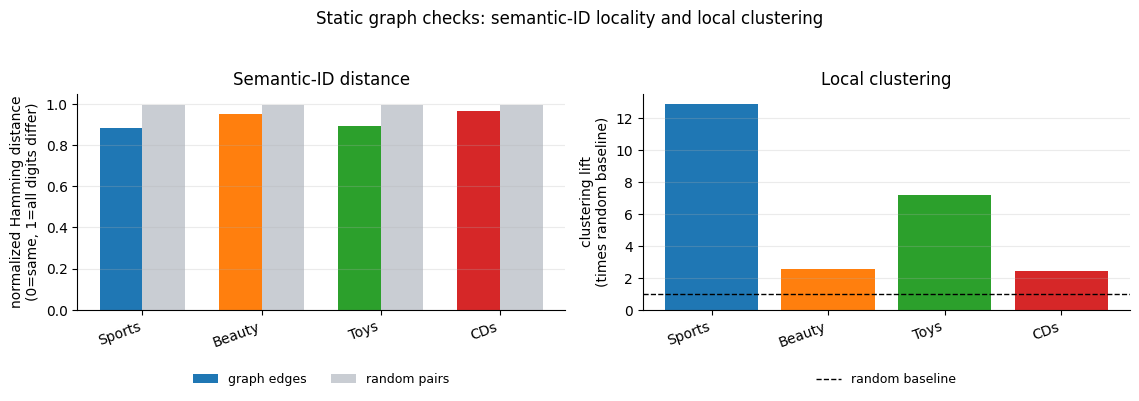

In [13]:
static_max = (
    static.sort_values(['dataset', 'k'])
    .groupby('dataset', as_index=False)
    .tail(1)
    .set_index('dataset')
    .loc[dataset_order]
    .reset_index()
)
static_story = static_max[[
    'dataset', 'k', 'largest_component_fraction',
    'normalized_hamming_mean', 'random_normalized_hamming_mean',
    'clustering_lift_over_random',
]].copy()
static_story['largest_component_fraction'] *= 100
display(static_story.rename(columns={
    'largest_component_fraction': 'largest weak component (%)',
    'normalized_hamming_mean': 'normalized SID Hamming',
    'random_normalized_hamming_mean': 'random normalized SID Hamming',
    'clustering_lift_over_random': 'clustering lift (x random)',
}).round(3))

x = np.arange(len(static_story))
bar_colors = [colors[name] for name in static_story['dataset']]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

width = 0.36
axes[0].bar(x - width / 2, static_story['normalized_hamming_mean'], width, label='graph edges', color=bar_colors)
axes[0].bar(x + width / 2, static_story['random_normalized_hamming_mean'], width, label='random pairs', color='#C9CDD3')
axes[0].set_title('Semantic-ID distance')
axes[0].set_ylabel('normalized Hamming distance\n(0=same, 1=all digits differ)')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.24), ncol=2)

axes[1].bar(x, static_story['clustering_lift_over_random'], color=bar_colors)
axes[1].axhline(1, color='black', linestyle='--', linewidth=1, label='random baseline')
axes[1].set_title('Local clustering')
axes[1].set_ylabel('clustering lift\n(times random baseline)')
axes[1].legend(fontsize=9, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.24))

for axis in axes:
    axis.set_xticks(x)
    axis.set_xticklabels(static_story['dataset'], rotation=20, ha='right')
    axis.grid(axis='y', alpha=0.25)
    axis.spines[['top', 'right']].set_visible(False)

fig.suptitle('Static graph checks: semantic-ID locality and local clustering', y=1.03)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

**Takeaway.** The graph is not globally broken: the largest weak component is 100% for all datasets at the largest tested graph budget, edges are more similar than random, SID distances are lower than random, and neighborhoods are reciprocal/clustered. Saturation is therefore unlikely to be explained by a disconnected or random graph.

## RQ2-B: Does larger graph budget improve reachability more than ranking?

**Hypothesis.** If graph budget is the bottleneck, reachability gains should translate into comparable ranking gains. If ranking saturates while reachability keeps increasing, the bottleneck is probably downstream of graph access.

,dataset,n_edges_start,n_edges_end,reachability_gain_pp,ndcg@10_gain_pp
0,Sports,10,100,51.49,0.34
1,Beauty,20,200,51.52,1.48
2,Toys,10,100,56.47,0.56
3,CDs,50,500,35.77,1.32


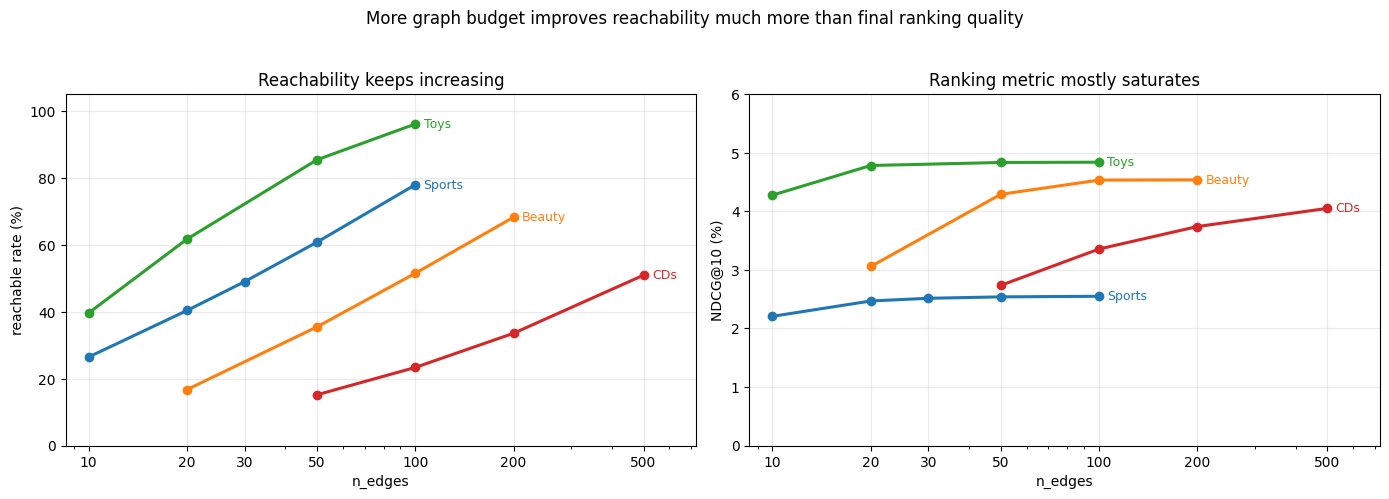

In [14]:
delta_rows = []
for dataset, group in dynamic.sort_values(['dataset', 'n_edges']).groupby('dataset', sort=False):
    first = group.iloc[0]
    last = group.iloc[-1]
    delta_rows.append({
        'dataset': dataset,
        'n_edges_start': int(first['n_edges']),
        'n_edges_end': int(last['n_edges']),
        'reachability_gain_pp': 100 * (last['reachable_rate'] - first['reachable_rate']),
        'ndcg@10_gain_pp': 100 * (last['ndcg@10'] - first['ndcg@10']),
    })
delta = pd.DataFrame(delta_rows).set_index('dataset').loc[dataset_order].reset_index()
display(delta.round(2))

all_edges = sorted(dynamic['n_edges'].unique())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for dataset, group in dynamic.groupby('dataset', sort=False):
    group = group.sort_values('n_edges')
    reach_pct = 100 * group['reachable_rate']
    ndcg_pct = 100 * group['ndcg@10']
    color = colors[dataset]
    axes[0].plot(group['n_edges'], reach_pct, marker='o', linewidth=2.2, markersize=6, color=color)
    axes[1].plot(group['n_edges'], ndcg_pct, marker='o', linewidth=2.2, markersize=6, color=color)
    axes[0].annotate(dataset, (group['n_edges'].iloc[-1], reach_pct.iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=color, fontsize=9)
    axes[1].annotate(dataset, (group['n_edges'].iloc[-1], ndcg_pct.iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=color, fontsize=9)

axes[0].set_title('Reachability keeps increasing')
axes[0].set_ylabel('reachable rate (%)')
axes[0].set_ylim(0, 105)
axes[1].set_title('Ranking metric mostly saturates')
axes[1].set_ylabel('NDCG@10 (%)')
axes[1].set_ylim(0, max(6, 115 * dynamic['ndcg@10'].max()))
for axis in axes:
    axis.set_xlabel('n_edges')
    axis.set_xscale('log')
    axis.set_xlim(min(all_edges) * 0.85, max(all_edges) * 1.45)
    axis.set_xticks(all_edges)
    axis.set_xticklabels([str(edge) for edge in all_edges])
    axis.grid(alpha=0.25)

fig.suptitle('More graph budget improves reachability much more than final ranking quality', y=1.03)
plt.tight_layout()
plt.show()

**Takeaway.** Reachability gains are large, but NDCG@10 gains are small. This supports the interpretation that additional graph traversal mainly improves candidate access, while final ranking quality saturates.

## RQ3: Is graph search still the bottleneck?

**Hypothesis.** If graph search is the main bottleneck, brute-force RPG scoring over all items should substantially outperform high-budget graph decoding. If high-budget graph decoding nearly matches brute force, the bottleneck is the scorer/ranker.

,dataset,n_edges,graph_ndcg@10,bf_ndcg@10,ndcg_loss_vs_bf_pp,top10_overlap_%
0,Sports,100,0.026,0.026,0.001,99.776
1,Beauty,200,0.045,0.046,0.015,96.330
2,Toys,100,0.048,0.048,0.000,99.973
3,CDs,500,0.041,0.042,0.139,80.574


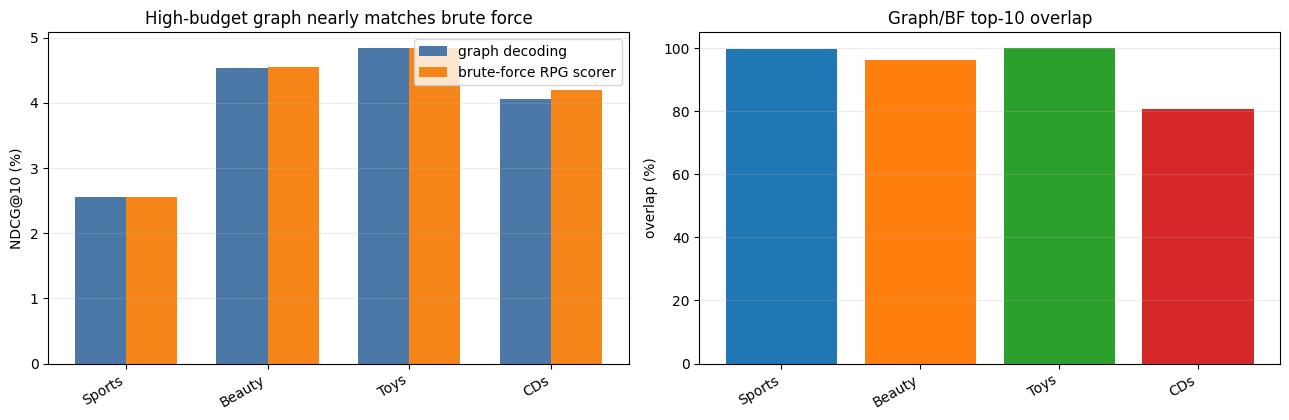

In [15]:
mean_scoring = scoring[scoring['aggregate'] == 'mean_across_seeds'].copy()
scoring_max = (
    mean_scoring.sort_values(['dataset', 'n_edges'])
    .groupby('dataset', as_index=False)
    .tail(1)
    .set_index('dataset')
    .loc[dataset_order]
    .reset_index()
)
bf_one = bf.set_index('dataset').loc[dataset_order].reset_index()
bf_lookup = dict(zip(bf_one['dataset'], bf_one['bf_ndcg@10']))
scoring_max['bf_ndcg@10'] = scoring_max['dataset'].map(bf_lookup)
scoring_max['ndcg_loss_vs_bf_pp'] = 100 * (scoring_max['bf_ndcg@10'] - scoring_max['graph_ndcg@10'])
scoring_max['top10_overlap_%'] = 100 * scoring_max['graph_top10_overlap_bf_top10_frac_mean']

display(scoring_max[[
    'dataset', 'n_edges', 'graph_ndcg@10', 'bf_ndcg@10', 'ndcg_loss_vs_bf_pp', 'top10_overlap_%'
]].round(3))

x = np.arange(len(scoring_max))
width = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].bar(x - width / 2, 100 * scoring_max['graph_ndcg@10'], width, label='graph decoding', color='#4C78A8')
axes[0].bar(x + width / 2, 100 * scoring_max['bf_ndcg@10'], width, label='brute-force RPG scorer', color='#F58518')
axes[0].set_title('High-budget graph nearly matches brute force')
axes[0].set_ylabel('NDCG@10 (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(scoring_max['dataset'], rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(x, scoring_max['top10_overlap_%'], color=[colors[name] for name in scoring_max['dataset']])
axes[1].set_title('Graph/BF top-10 overlap')
axes[1].set_ylabel('overlap (%)')
axes[1].set_ylim(0, 105)
axes[1].set_xticks(x)
axes[1].set_xticklabels(scoring_max['dataset'], rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

**Takeaway.** At large graph budget, graph decoding nearly reaches the brute-force RPG scorer. Therefore, the remaining performance ceiling is mostly the RPG scorer/ranker, not graph reachability/search.

## Main-text recommendation

Use these as the main graph figures:

1. **Static graph structure:** one compact cross-dataset figure/table showing the graph is not broken.
2. **Reachability vs NDCG:** one two-panel cross-dataset figure showing reachability improves much more than final ranking quality.
3. **Graph vs brute-force scorer:** one compact figure/table showing high-budget graph decoding nearly matches brute-force RPG scoring.

Move histograms, popularity buckets, first-hit curves, and B7 beam-budget diagnostics to appendix or omit from the main story.